In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
import os, time, warnings
warnings.filterwarnings('ignore')

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("models",  exist_ok=True)
os.makedirs("results", exist_ok=True)

In [2]:
class WeatherModel:
    """
    Simulates physical weather forces acting on the drone.

    3 difficulty levels:
      0 = Calm  : wind 0-2 m/s,  rain 0-5 mm/h,  turbulence std=0.1
      1 = Windy : wind 0-8 m/s,  rain 0-25 mm/h, turbulence std=0.5
      2 = Storm : wind 0-15 m/s, rain 0-50 mm/h, turbulence std=1.5

    Returns force vector [fx, fy, fz] in Newtons.
    """

    LEVELS = {
        0: {"name": "Calm",  "wind": 2.0,  "rain": 5.0,  "turb": 0.1},
        1: {"name": "Windy", "wind": 8.0,  "rain": 25.0, "turb": 0.5},
        2: {"name": "Storm", "wind": 15.0, "rain": 50.0, "turb": 1.5},
    }

    def __init__(self, difficulty=0):
        self.set_difficulty(difficulty)

    def set_difficulty(self, level):
        self.difficulty = level
        cfg = self.LEVELS[level]
        self.wind_max = cfg["wind"]
        self.rain_max = cfg["rain"]
        self.turb_std = cfg["turb"]
        self.name     = cfg["name"]

    def get_forces(self):
        """Returns [fx, fy, fz] disturbance force vector in Newtons"""
        # Wind: random speed and direction
        wind_speed = np.random.uniform(0, self.wind_max)
        wind_dir   = np.random.uniform(0, 2 * np.pi)
        fx = wind_speed * np.cos(wind_dir)
        fy = wind_speed * np.sin(wind_dir)

        # Turbulence: random vertical force
        fz = np.random.normal(0, self.turb_std)

        # Rain: adds downward drag force
        rain = np.random.uniform(0, self.rain_max)
        fz -= rain * 0.01

        return np.array([fx, fy, fz], dtype=np.float32)

    def get_obs(self):
        """Normalized weather observation for the agent (range ~-1 to 1)"""
        return self.get_forces() / 15.0

    def __repr__(self):
        return f"WeatherModel(level={self.difficulty} '{self.name}' wind_max={self.wind_max})"


# ── Quick test ──────────────────────────────────────────────
print("Testing WeatherModel at all 3 levels:")
for lvl in [0, 1, 2]:
    w = WeatherModel(difficulty=lvl)
    f = w.get_forces()
    print(f"  {w.name:6s}: forces={f.round(2)}, magnitude={np.linalg.norm(f):.2f}N")
print("✅ WeatherModel works!")

Testing WeatherModel at all 3 levels:
  Calm  : forces=[ 0.03 -0.02  0.  ], magnitude=0.04N
  Windy : forces=[-0.38  2.24  0.1 ], magnitude=2.28N
  Storm : forces=[ 2.07  6.79 -1.67], magnitude=7.29N
✅ WeatherModel works!


In [3]:
class DroneWeatherEnv(gym.Env):
    """
    6-DOF Drone Environment with Weather Disturbances.

    STATE  (12,) : [x, y, z,         ← position
                    vx, vy, vz,       ← velocity
                    roll, pitch, yaw, ← orientation angles
                    wx, wy, wz]       ← weather observation (normalized)

    ACTION (4,)  : [thrust, roll_cmd, pitch_cmd, yaw_cmd]  all in [-1, 1]

    GOAL         : Hover stably at position [0, 0, 5] metres

    REWARD       : -distance*2 - speed*0.1 - tilt*0.5
                   +5 if dist < 0.5m  (close bonus)
                   +20 if dist < 0.3m (success)
                   -20 if crashed or out of bounds
    """

    def __init__(self, difficulty=0):
        super().__init__()
        self.max_steps = 200
        self.dt        = 0.05   # 50ms timestep
        self.mass      = 1.0   # 1 kg drone
        self.gravity   = 9.81
        self.target    = np.array([0.0, 0.0, 5.0], dtype=np.float32)
        self.weather   = WeatherModel(difficulty)
        self.step_count = 0
        self.state      = np.zeros(9, dtype=np.float32)  # [pos(3), vel(3), angles(3)]

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(12,), dtype=np.float32)
        self.action_space = spaces.Box(
            low=np.float32(-1.0), high=np.float32(1.0),
            shape=(4,), dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.zeros(9, dtype=np.float32)
        # Random start near origin
        self.state[0:3] = np.random.uniform(-0.5, 0.5, 3).astype(np.float32)
        self.state[2]   = np.float32(np.random.uniform(0.5, 2.0))  # start altitude
        self.step_count  = 0
        return self._get_obs(), {}

    def _get_obs(self):
        """Concatenate drone state with weather observation"""
        weather_obs = self.weather.get_obs()
        return np.concatenate([self.state, weather_obs]).astype(np.float32)

    def step(self, action):
        self.step_count += 1
        action = np.clip(action, -1.0, 1.0).astype(np.float32)

        # ── Scale actions to physical values ────────────────────
        thrust    = (action[0] + 1) * 0.5 * 20.0   # 0 to 20 Newtons
        roll_cmd  = float(action[1]) * 0.3          # radians
        pitch_cmd = float(action[2]) * 0.3
        yaw_cmd   = float(action[3]) * 0.3

        pos    = self.state[0:3].copy()
        vel    = self.state[3:6].copy()
        angles = self.state[6:9].copy()

        # ── 6-DOF Dynamics ──────────────────────────────────────
        # Thrust vector in world frame (depends on roll/pitch angles)
        thrust_vec = np.array([
            thrust * np.sin(angles[1]),                           # x from pitch
            -thrust * np.sin(angles[0]),                          # y from roll
            thrust * np.cos(angles[0]) * np.cos(angles[1]),     # z upward
        ], dtype=np.float32)

        gravity_vec   = np.array([0, 0, -self.mass * self.gravity], dtype=np.float32)
        weather_force = self.weather.get_forces()

        net_force = thrust_vec + gravity_vec + weather_force
        acc       = net_force / self.mass

        # Euler integration
        vel_new = vel + acc * self.dt
        pos_new = pos + vel_new * self.dt

        # Update angles toward commanded values
        angle_rate  = 5.0
        angles_new  = angles + np.array([
            roll_cmd  - angles[0],
            pitch_cmd - angles[1],
            yaw_cmd   - angles[2],
        ], dtype=np.float32) * self.dt * angle_rate

        # Update state
        self.state[0:3] = pos_new
        self.state[3:6] = vel_new
        self.state[6:9] = angles_new

        # ── Reward Calculation ──────────────────────────────────
        dist  = float(np.linalg.norm(pos_new - self.target))
        speed = float(np.linalg.norm(vel_new))
        tilt  = float(np.abs(angles_new[0]) + np.abs(angles_new[1]))

        reward = (-dist * 2.0       # penalize distance from target
                  - speed * 0.1    # penalize fast movement
                  - tilt * 0.5)    # penalize tilting

        if dist < 0.5:  reward += 5.0    # bonus: near target
        if dist < 0.3:  reward += 10.0   # bonus: very close (success zone)

        # ── Termination ─────────────────────────────────────────
        crashed      = bool(pos_new[2] < 0.0)
        out_of_range = bool(np.any(np.abs(pos_new) > 20.0))
        reached      = bool(dist < 0.3)
        truncated    = bool(self.step_count >= self.max_steps)
        terminated   = crashed or out_of_range or reached

        if crashed or out_of_range:  reward -= 20.0
        if reached:                   reward += 20.0

        info = {
            "distance": dist,
            "crashed":  crashed,
            "reached":  reached,
            "weather":  self.weather.name,
            "steps":    self.step_count,
        }
        return self._get_obs(), float(reward), terminated, truncated, info

    def set_difficulty(self, level):
        self.weather.set_difficulty(level)


print("✅ DroneWeatherEnv defined!")
print(f"Observation space: {DroneWeatherEnv().observation_space}")
print(f"Action space:      {DroneWeatherEnv().action_space}")

✅ DroneWeatherEnv defined!
Observation space: Box(-inf, inf, (12,), float32)
Action space:      Box(-1.0, 1.0, (4,), float32)


In [4]:
class MCDropoutNetwork(nn.Module):
    """
    Neural network with Monte Carlo Dropout for uncertainty estimation.

    HOW IT WORKS:
    - Normal networks: dropout OFF during inference (deterministic)
    - This network:   dropout ON during inference (stochastic)

    By running the forward pass N times, we get N different outputs.
    The VARIANCE of these outputs = our uncertainty estimate.

    From your PPT:
      Clear weather → outputs [2.1, 2.0, 2.1] → variance = 0.002  ← CONFIDENT
      Storm         → outputs [2.1, 5.4, -1.2] → variance = 4.56  ← UNCERTAIN

    High uncertainty → agent activates SAFE MODE (conservative actions)
    """

    def __init__(self, input_dim, output_dim, hidden=256, dropout_p=0.1):
        super().__init__()
        self.dropout_p = dropout_p

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),        # stays ON during inference!
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden, output_dim),
        )

    def forward(self, x):
        return self.net(x)

    def mc_predict(self, x, n=10):
        """
        Run N stochastic forward passes.
        Returns: (mean_prediction, variance_across_runs)
        High variance = high uncertainty = safe mode needed
        """
        self.train()   # CRITICAL: keeps dropout active during inference
        predictions = []
        with torch.no_grad():
            for _ in range(n):
                pred = self.forward(x)
                predictions.append(pred)

        stacked  = torch.stack(predictions)      # shape: [N, batch, output_dim]
        mean     = stacked.mean(dim=0)           # average prediction
        variance = stacked.var(dim=0).mean().item()  # scalar uncertainty
        return mean, variance

    def is_uncertain(self, x, threshold=0.5):
        """Returns (is_uncertain: bool, variance: float)"""
        _, var = self.mc_predict(x)
        return var > threshold, var


# ── Demo: show MC Dropout uncertainty estimation ────────────
print("🔬 MC Dropout Uncertainty Demo:")
print("="*50)

net = MCDropoutNetwork(input_dim=12, output_dim=4)

# Calm: small consistent inputs → low variance
x_calm = torch.randn(1, 12) * 0.1
_, var_calm = net.mc_predict(x_calm, n=10)

# Storm: large wild inputs → high variance
x_storm = torch.randn(1, 12) * 5.0
_, var_storm = net.mc_predict(x_storm, n=10)

print(f"Calm  (small inputs)  → variance = {var_calm:.4f}  ← confident")
print(f"Storm (large inputs)  → variance = {var_storm:.4f}  ← uncertain")
print(f"\nSafe mode threshold: 0.5")
print(f"Storm uncertain? {var_storm > 0.5}")
print("\n✅ MCDropoutNetwork works!")

🔬 MC Dropout Uncertainty Demo:
Calm  (small inputs)  → variance = 0.0003  ← confident
Storm (large inputs)  → variance = 0.0270  ← uncertain

Safe mode threshold: 0.5
Storm uncertain? False

✅ MCDropoutNetwork works!


In [5]:
class PPOAgent:
    """
    Proximal Policy Optimization (PPO) Agent
    with Uncertainty-Aware action selection.

    PPO clip loss:
      ratio = new_prob / old_prob
      L = -min( ratio * advantage,
                clip(ratio, 1-ε, 1+ε) * advantage )

    Uncertainty-Aware action:
      If MC Dropout variance > threshold:
        → reduce action std by 70% (safer, smaller movements)
    """

    def __init__(self, obs_dim, act_dim,
                 lr=3e-4, gamma=0.99, clip_eps=0.2, epochs=10):
        self.gamma    = gamma
        self.clip_eps = clip_eps
        self.epochs   = epochs

        # Actor: outputs mean action values
        self.actor   = MCDropoutNetwork(obs_dim, act_dim).to(DEVICE)
        self.log_std = nn.Parameter(torch.zeros(act_dim).to(DEVICE))

        # Critic: outputs state value estimate
        self.critic  = MCDropoutNetwork(obs_dim, 1).to(DEVICE)

        self.actor_opt  = optim.Adam(
            list(self.actor.parameters()) + [self.log_std], lr=lr)
        self.critic_opt = optim.Adam(
            self.critic.parameters(), lr=lr)

        self.uncertainty_threshold = 0.5
        self.safe_mode_count       = 0    # for logging

    def get_action(self, obs):
        """
        Select action with uncertainty check.
        Returns: (action, log_prob, uncertainty_variance)
        """
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        mean, uncertainty = self.actor.mc_predict(obs_t, n=10)
        std = self.log_std.exp()

        # ── SAFE MODE: uncertain → smaller actions ───────────────
        if uncertainty > self.uncertainty_threshold:
            std = std * 0.3    # reduce std → more conservative
            self.safe_mode_count += 1

        dist     = torch.distributions.Normal(mean, std)
        action   = dist.sample()
        log_prob = dist.log_prob(action).sum(dim=-1)

        action_np = action.squeeze(0).detach().cpu().numpy()
        action_np = np.clip(action_np, -1.0, 1.0)
        return action_np, log_prob.item(), uncertainty

    def get_value(self, obs):
        """Get critic's estimate of state value"""
        obs_t = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        self.critic.eval()
        with torch.no_grad():
            val = self.critic(obs_t)
        return val.item()

    def compute_returns(self, rewards, dones, last_value):
        """Compute discounted returns (backwards pass)"""
        returns = []
        R = last_value
        for r, done in zip(reversed(rewards), reversed(dones)):
            R = r + self.gamma * R * (1.0 - done)
            returns.insert(0, R)
        return returns

    def update(self, buffer):
        """Run PPO update on collected experience buffer"""
        obs      = torch.FloatTensor(np.array(buffer["obs"])).to(DEVICE)
        actions  = torch.FloatTensor(np.array(buffer["actions"])).to(DEVICE)
        old_lp   = torch.FloatTensor(np.array(buffer["log_probs"])).to(DEVICE)
        returns  = torch.FloatTensor(np.array(buffer["returns"])).to(DEVICE)
        values   = torch.FloatTensor(np.array(buffer["values"])).to(DEVICE)

        # Advantages = returns - baseline values
        advs = returns - values
        advs = (advs - advs.mean()) / (advs.std() + 1e-8)

        actor_losses, critic_losses = [], []

        for _ in range(self.epochs):
            # ── Actor (policy) update ────────────────────────────
            self.actor.train()
            means  = self.actor(obs)
            std    = self.log_std.exp()
            dist   = torch.distributions.Normal(means, std)
            new_lp = dist.log_prob(actions).sum(dim=-1)

            ratio  = (new_lp - old_lp).exp()
            clip_r = torch.clamp(ratio, 1 - self.clip_eps,
                                         1 + self.clip_eps)
            # PPO clipped objective
            actor_loss = -torch.min(ratio * advs, clip_r * advs).mean()

            self.actor_opt.zero_grad()
            actor_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.actor_opt.step()

            # ── Critic (value) update ────────────────────────────
            self.critic.train()
            v_pred      = self.critic(obs).squeeze()
            critic_loss = nn.MSELoss()(v_pred, returns)

            self.critic_opt.zero_grad()
            critic_loss.backward()
            self.critic_opt.step()

            actor_losses.append(actor_loss.item())
            critic_losses.append(critic_loss.item())

        return np.mean(actor_losses), np.mean(critic_losses)

    def save(self, path):
        torch.save({
            "actor":   self.actor.state_dict(),
            "critic":  self.critic.state_dict(),
            "log_std": self.log_std.data,
        }, path)
        print(f"💾 Saved → {path}")

    def load(self, path):
        ckpt = torch.load(path, map_location=DEVICE)
        self.actor.load_state_dict(ckpt["actor"])
        self.critic.load_state_dict(ckpt["critic"])
        self.log_std.data = ckpt["log_std"]
        print(f"✅ Loaded ← {path}")


# ── Quick test ──────────────────────────────────────────────
agent = PPOAgent(obs_dim=12, act_dim=4)
print(f"✅ PPOAgent created!")
print(f"   Actor  params: {sum(p.numel() for p in agent.actor.parameters()):,}")
print(f"   Critic params: {sum(p.numel() for p in agent.critic.parameters()):,}")

# Test action selection
env  = DroneWeatherEnv(difficulty=0)
obs, _ = env.reset()
action, log_prob, uncertainty = agent.get_action(obs)
print(f"\nSample action:    {action.round(3)}")
print(f"Log probability:  {log_prob:.4f}")
print(f"Uncertainty:      {uncertainty:.4f}")
print(f"Safe mode active: {uncertainty > 0.5}")

✅ PPOAgent created!
   Actor  params: 70,148
   Critic params: 69,377

Sample action:    [-0.119 -0.438 -1.    -1.   ]
Log probability:  -4.7489
Uncertainty:      0.0003
Safe mode active: False


In [6]:
# ── Hyperparameters ─────────────────────────────────────────
CONFIG = {
    "obs_dim":    12,
    "act_dim":    4,
    "lr":         3e-4,
    "gamma":      0.99,
    "clip_eps":   0.2,
    "ppo_epochs": 10,
    "calm_eps":   300,     # episodes for calm phase
    "windy_eps":  300,     # episodes for windy phase
    "storm_eps":  400,     # episodes for storm phase
    "save_every": 100,     # save checkpoint every N episodes
    "print_every":25,      # print progress every N episodes
}
TOTAL_EPS = CONFIG["calm_eps"] + CONFIG["windy_eps"] + CONFIG["storm_eps"]
print(f"Total training episodes: {TOTAL_EPS}")


class CurriculumScheduler:
    """
    Manages progressive difficulty increase.
    Phase 1: Calm  (difficulty 0) — 300 episodes
    Phase 2: Windy (difficulty 1) — 300 episodes
    Phase 3: Storm (difficulty 2) — 400 episodes
    """
    def __init__(self, calm, windy, storm):
        self.phases = [
            {"name": "🟢 Calm",  "level": 0, "eps": calm},
            {"name": "🟡 Windy", "level": 1, "eps": windy},
            {"name": "🔴 Storm", "level": 2, "eps": storm},
        ]
        self.phase_idx   = 0
        self.ep_in_phase = 0
        self.total_ep    = 0

    def step(self):
        """Call once per episode. Returns current difficulty level (0/1/2)."""
        phase = self.phases[self.phase_idx]
        self.ep_in_phase += 1
        self.total_ep    += 1

        if (self.ep_in_phase >= phase["eps"]
                and self.phase_idx < len(self.phases) - 1):
            self.phase_idx   += 1
            self.ep_in_phase  = 0
            next_name = self.phases[self.phase_idx]["name"]
            print(f"\n{'='*50}")
            print(f"🔔 CURRICULUM ADVANCE → {next_name}")
            print(f"{'='*50}")
        return phase["level"]

    @property
    def name(self):
        return self.phases[self.phase_idx]["name"]


print("✅ Config and CurriculumScheduler ready")

Total training episodes: 1000
✅ Config and CurriculumScheduler ready


In [7]:
def collect_episode(env, agent):
    """
    Run one full episode and collect all experience.
    Returns: (buffer_dict, episode_info_dict)
    """
    obs, _ = env.reset()
    buffer = {
        "obs":         [],
        "actions":     [],
        "log_probs":   [],
        "rewards":     [],
        "dones":       [],
        "values":      [],
        "uncertainties": [],
    }
    done = False

    while not done:
        action, log_prob, uncertainty = agent.get_action(obs)
        value = agent.get_value(obs)
        next_obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        buffer["obs"].append(obs)
        buffer["actions"].append(action)
        buffer["log_probs"].append(log_prob)
        buffer["rewards"].append(reward)
        buffer["dones"].append(float(done))
        buffer["values"].append(value)
        buffer["uncertainties"].append(uncertainty)
        obs = next_obs

    # Compute discounted returns
    last_val = agent.get_value(obs) if not terminated else 0.0
    buffer["returns"] = agent.compute_returns(
        buffer["rewards"], buffer["dones"], last_val)

    ep_info = {
        "total_reward": sum(buffer["rewards"]),
        "steps":        len(buffer["rewards"]),
        "success":      info.get("reached", False),
        "crashed":      info.get("crashed", False),
        "final_dist":   info.get("distance", 999),
        "avg_uncert":   float(np.mean(buffer["uncertainties"])),
    }
    return buffer, ep_info


def smooth(data, window=30):
    """Moving average for plotting"""
    return pd.Series(data).rolling(window, min_periods=1).mean().values


print("✅ Helper functions ready")

✅ Helper functions ready


In [8]:
# ════════════════════════════════════════════════════════════
# 🚀 MAIN TRAINING LOOP
# ════════════════════════════════════════════════════════════
print("🚁 Starting Drone RL Training...")
print(f"Device    : {DEVICE}")
print(f"Episodes  : {TOTAL_EPS} (Calm:{CONFIG['calm_eps']} | Windy:{CONFIG['windy_eps']} | Storm:{CONFIG['storm_eps']})")
print("="*60)

# Initialize agent and curriculum
agent      = PPOAgent(CONFIG["obs_dim"], CONFIG["act_dim"],
                       lr=CONFIG["lr"], gamma=CONFIG["gamma"],
                       clip_eps=CONFIG["clip_eps"], epochs=CONFIG["ppo_epochs"])
curriculum = CurriculumScheduler(
    CONFIG["calm_eps"], CONFIG["windy_eps"], CONFIG["storm_eps"])

# Logging dictionaries
log = {
    "episode":     [],
    "reward":      [],
    "success":     [],
    "crashed":     [],
    "difficulty":  [],
    "uncertainty": [],
    "actor_loss":  [],
    "critic_loss": [],
    "final_dist":  [],
}

start_time = time.time()

for ep in range(1, TOTAL_EPS + 1):

    # Get current curriculum level
    level = curriculum.step()
    env   = DroneWeatherEnv(difficulty=level)

    # Collect one episode of experience
    buffer, ep_info = collect_episode(env, agent)

    # Update agent with PPO
    a_loss, c_loss = agent.update(buffer)

    # Log everything
    log["episode"].append(ep)
    log["reward"].append(ep_info["total_reward"])
    log["success"].append(float(ep_info["success"]))
    log["crashed"].append(float(ep_info["crashed"]))
    log["difficulty"].append(level)
    log["uncertainty"].append(ep_info["avg_uncert"])
    log["actor_loss"].append(a_loss)
    log["critic_loss"].append(c_loss)
    log["final_dist"].append(ep_info["final_dist"])

    # Print progress
    if ep % CONFIG["print_every"] == 0:
        recent_n  = min(50, ep)
        recent_sr = np.mean(log["success"][-recent_n:]) * 100
        recent_r  = np.mean(log["reward"][-recent_n:])
        elapsed   = (time.time() - start_time) / 60
        remaining = elapsed / ep * (TOTAL_EPS - ep)
        print(f"Ep {ep:4d}/{TOTAL_EPS} | {curriculum.name} | "
              f"SR:{recent_sr:5.1f}% | R:{recent_r:7.1f} | "
              f"U:{ep_info['avg_uncert']:.3f} | "
              f"⏱{elapsed:.1f}m (est.{remaining:.0f}m left)")

    # Save checkpoint
    if ep % CONFIG["save_every"] == 0:
        agent.save(f"models/checkpoint_ep{ep}.pt")

# Save final model
agent.save("models/drone_final.pt")
total_time = (time.time() - start_time) / 60
final_sr   = np.mean(log["success"][-100:]) * 100

print("\n" + "="*60)
print(f"🎉 TRAINING COMPLETE!")
print(f"   Total time       : {total_time:.1f} minutes")
print(f"   Final 100-ep SR  : {final_sr:.1f}%")
print(f"   Safe mode count  : {agent.safe_mode_count}")
print("="*60)

🚁 Starting Drone RL Training...
Device    : cpu
Episodes  : 1000 (Calm:300 | Windy:300 | Storm:400)
Ep   25/1000 | 🟢 Calm | SR:  0.0% | R: -225.5 | U:0.028 | ⏱0.1m (est.3m left)
Ep   50/1000 | 🟢 Calm | SR:  0.0% | R: -183.0 | U:0.052 | ⏱0.1m (est.3m left)
Ep   75/1000 | 🟢 Calm | SR:  0.0% | R: -133.3 | U:0.022 | ⏱0.2m (est.2m left)
Ep  100/1000 | 🟢 Calm | SR:  0.0% | R: -124.9 | U:0.031 | ⏱0.3m (est.2m left)
💾 Saved → models/checkpoint_ep100.pt
Ep  125/1000 | 🟢 Calm | SR:  0.0% | R: -117.8 | U:0.023 | ⏱0.3m (est.2m left)
Ep  150/1000 | 🟢 Calm | SR:  0.0% | R: -114.5 | U:0.070 | ⏱0.4m (est.2m left)
Ep  175/1000 | 🟢 Calm | SR:  0.0% | R: -113.7 | U:0.040 | ⏱0.5m (est.2m left)
Ep  200/1000 | 🟢 Calm | SR:  0.0% | R: -110.9 | U:0.049 | ⏱0.5m (est.2m left)
💾 Saved → models/checkpoint_ep200.pt
Ep  225/1000 | 🟢 Calm | SR:  0.0% | R: -111.5 | U:0.038 | ⏱0.6m (est.2m left)
Ep  250/1000 | 🟢 Calm | SR:  0.0% | R: -111.2 | U:0.100 | ⏱0.6m (est.2m left)
Ep  275/1000 | 🟢 Calm | SR:  0.0% | R: -110.9 

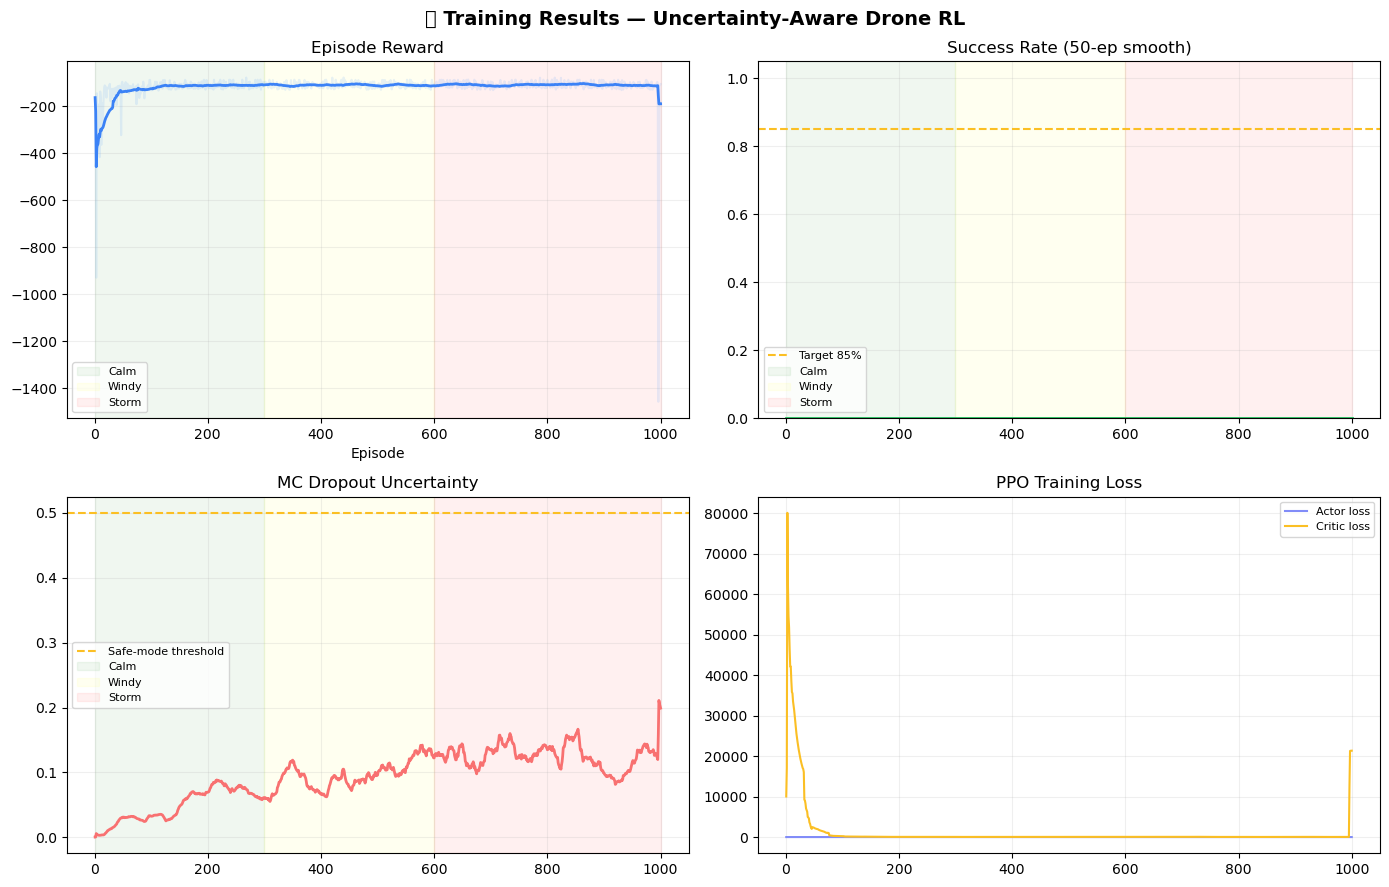

✅ Training curves saved → results/nb3_training_curves.png
➡️  Open Notebook 4 for testing.


In [9]:
# ── Training Curve Plots ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("🚁 Training Results — Uncertainty-Aware Drone RL",
             fontsize=14, fontweight="bold")

eps = log["episode"]
c1 = CONFIG["calm_eps"]
c2 = c1 + CONFIG["windy_eps"]

def shade_phases(ax):
    ax.axvspan(1,  c1, alpha=0.06, color="green",  label="Calm")
    ax.axvspan(c1, c2, alpha=0.06, color="yellow", label="Windy")
    ax.axvspan(c2, TOTAL_EPS, alpha=0.06, color="red", label="Storm")

# 1. Reward
axes[0,0].plot(eps, log["reward"], alpha=0.15, color="#60a5fa")
axes[0,0].plot(eps, smooth(log["reward"]), color="#3b82f6", lw=2)
shade_phases(axes[0,0])
axes[0,0].set_title("Episode Reward"); axes[0,0].set_xlabel("Episode")
axes[0,0].legend(fontsize=8); axes[0,0].grid(True, alpha=0.2)

# 2. Success rate
axes[0,1].plot(eps, smooth(log["success"], 50), color="#22c55e", lw=2)
axes[0,1].axhline(0.85, color="#fbbf24", linestyle="--", label="Target 85%")
shade_phases(axes[0,1])
axes[0,1].set_title("Success Rate (50-ep smooth)")
axes[0,1].set_ylim(0, 1.05); axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.2)

# 3. Uncertainty over time
axes[1,0].plot(eps, smooth(log["uncertainty"]), color="#f87171", lw=2)
axes[1,0].axhline(0.5, color="#fbbf24", linestyle="--", label="Safe-mode threshold")
shade_phases(axes[1,0])
axes[1,0].set_title("MC Dropout Uncertainty")
axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.2)

# 4. PPO Loss
axes[1,1].plot(eps, smooth(log["actor_loss"]),  label="Actor loss",  color="#818cf8")
axes[1,1].plot(eps, smooth(log["critic_loss"]), label="Critic loss", color="#fbbf24")
axes[1,1].set_title("PPO Training Loss")
axes[1,1].legend(fontsize=8); axes[1,1].grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("results/nb3_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Training curves saved → results/nb3_training_curves.png")
print("➡️  Open Notebook 4 for testing.")

In [10]:
import os
print("Models saved:")
for f in os.listdir("models"): print(" ", f)
print("\nResult images saved:")
for f in os.listdir("results"): print(" ", f)

Models saved:
  checkpoint_ep100.pt
  checkpoint_ep1000.pt
  checkpoint_ep200.pt
  checkpoint_ep300.pt
  checkpoint_ep400.pt
  checkpoint_ep500.pt
  checkpoint_ep600.pt
  checkpoint_ep700.pt
  checkpoint_ep800.pt
  checkpoint_ep900.pt
  drone_final.pt

Result images saved:
  checkpoint-12
  nb1_env_test.png
  nb2_uncertainty_demo.png
  nb3_training_curves.png
  nb4_final_dashboard.png
  nb4_trajectory_calm.png
  nb4_trajectory_storm.png
  nb4_trajectory_windy.png


In [11]:
import os

# Check current location
print("Location:", os.getcwd())
print()

# Check if models folder exists
if os.path.exists("models"):
    print("✅ models folder FOUND!")
    print("Files inside:")
    for f in os.listdir("models"):
        print("  ", f)
else:
    print("❌ models folder NOT found")

print()

# Check if results folder exists
if os.path.exists("results"):
    print("✅ results folder FOUND!")
    print("Files inside:")
    for f in os.listdir("results"):
        print("  ", f)
else:
    print("❌ results folder NOT found")

Location: C:\Users\madhu\OneDrive\Desktop

✅ models folder FOUND!
Files inside:
   checkpoint_ep100.pt
   checkpoint_ep1000.pt
   checkpoint_ep200.pt
   checkpoint_ep300.pt
   checkpoint_ep400.pt
   checkpoint_ep500.pt
   checkpoint_ep600.pt
   checkpoint_ep700.pt
   checkpoint_ep800.pt
   checkpoint_ep900.pt
   drone_final.pt

✅ results folder FOUND!
Files inside:
   checkpoint-12
   nb1_env_test.png
   nb2_uncertainty_demo.png
   nb3_training_curves.png
   nb4_final_dashboard.png
   nb4_trajectory_calm.png
   nb4_trajectory_storm.png
   nb4_trajectory_windy.png
